# Intrusion Detection System (IDS) — Machine Learning
### Dataset: CIC-IDS-2018 | All 10 Parquet Files

| File | Attack Category |
|------|-----------------|
| Botnet-Friday-02-03-2018 | Botnet |
| Bruteforce-Wednesday-14-02-2018 | Bruteforce |
| DDoS1-Tuesday-20-02-2018 | DDoS |
| DDoS2-Wednesday-21-02-2018 | DDoS |
| DoS1-Thursday-15-02-2018 | DoS |
| DoS2-Friday-16-02-2018 | DoS |
| Infil1-Wednesday-28-02-2018 | Infiltration |
| Infil2-Thursday-01-03-2018 | Infiltration |
| Web1-Thursday-22-02-2018 | Web Attack |
| Web2-Friday-23-02-2018 | Web Attack |

**Includes:** Data Quality Check · Class Imbalance · Train/Test Split · 5-Fold Cross-Validation · Accuracy · Precision · Recall · F1-Score · Confusion Matrix · Classification Report · ROC Curve · False Positive Rate · Feature Importance · Save/Load Model · Custom Prediction

## Cell 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import time
import joblib

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc
)
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (7, 4)

print('All libraries imported successfully!')

All libraries imported successfully!


## Cell 2 — Load All 10 Parquet Files

In [2]:
DATASET_FOLDER = r'C:\Users\TGX-100\ETI_Miniproject\IDSDataset'

FILE_LABEL_MAP = {
    'Botnet-Friday-02-03-2018_TrafficForML_CICFlowMeter.parquet'        : 'Botnet',
    'Bruteforce-Wednesday-14-02-2018_TrafficForML_CICFlowMeter.parquet' : 'Bruteforce',
    'DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowMeter.parquet'        : 'DDoS',
    'DDoS2-Wednesday-21-02-2018_TrafficForML_CICFlowMeter.parquet'      : 'DDoS',
    'DoS1-Thursday-15-02-2018_TrafficForML_CICFlowMeter.parquet'        : 'DoS',
    'DoS2-Friday-16-02-2018_TrafficForML_CICFlowMeter.parquet'          : 'DoS',
    'Infil1-Wednesday-28-02-2018_TrafficForML_CICFlowMeter.parquet'     : 'Infiltration',
    'Infil2-Thursday-01-03-2018_TrafficForML_CICFlowMeter.parquet'      : 'Infiltration',
    'Web1-Thursday-22-02-2018_TrafficForML_CICFlowMeter.parquet'        : 'Web Attack',
    'Web2-Friday-23-02-2018_TrafficForML_CICFlowMeter.parquet'          : 'Web Attack'
}

SAMPLE_PER_FILE = 25000

dfs = []
print('Loading files...\n')

for filename, label in FILE_LABEL_MAP.items():
    filepath = os.path.join(DATASET_FOLDER, filename)
    if os.path.exists(filepath):
        df_temp = pd.read_parquet(filepath)
        if 'Label' in df_temp.columns:
            df_temp['Attack_Category'] = df_temp['Label'].apply(
                lambda x: 'Benign' if str(x).strip().lower() in ['benign', '0', 'normal']
                          else label
            )
        else:
            df_temp['Attack_Category'] = label
        if len(df_temp) > SAMPLE_PER_FILE:
            df_temp = df_temp.sample(n=SAMPLE_PER_FILE, random_state=42)
        dfs.append(df_temp)
        cats = df_temp['Attack_Category'].value_counts().to_dict()
        print(f'  Loaded: {filename[:52]:<52}  rows: {len(df_temp):>6,}   classes: {cats}')
    else:
        print(f'  NOT FOUND: {filename}')

df = pd.concat(dfs, ignore_index=True)

print(f'\nCombined shape : {df.shape}')
print(f'\nFull Class Distribution:')
print(df['Attack_Category'].value_counts())

Loading files...

  Loaded: Botnet-Friday-02-03-2018_TrafficForML_CICFlowMeter.p  rows: 25,000   classes: {'Benign': 20282, 'Botnet': 4718}
  Loaded: Bruteforce-Wednesday-14-02-2018_TrafficForML_CICFlow  rows: 25,000   classes: {'Benign': 21161, 'Bruteforce': 3839}
  Loaded: DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowMeter.p  rows: 25,000   classes: {'DDoS': 15175, 'Benign': 9825}
  Loaded: DDoS2-Wednesday-21-02-2018_TrafficForML_CICFlowMeter  rows: 25,000   classes: {'Benign': 16131, 'DDoS': 8869}
  Loaded: DoS1-Thursday-15-02-2018_TrafficForML_CICFlowMeter.p  rows: 25,000   classes: {'Benign': 23411, 'DoS': 1589}
  Loaded: DoS2-Friday-16-02-2018_TrafficForML_CICFlowMeter.par  rows: 25,000   classes: {'Benign': 18929, 'DoS': 6071}
  Loaded: Infil1-Wednesday-28-02-2018_TrafficForML_CICFlowMete  rows: 25,000   classes: {'Benign': 21879, 'Infiltration': 3121}
  Loaded: Infil2-Thursday-01-03-2018_TrafficForML_CICFlowMeter  rows: 25,000   classes: {'Benign': 18681, 'Infiltration': 6319}


## Cell 3 — Data Quality Check

In [3]:
print('=' * 50)
print('        DATA QUALITY REPORT')
print('=' * 50)
print(f'Total rows     : {len(df):,}')
print(f'Total columns  : {len(df.columns)}')

# Missing values
missing = df.isnull().sum()
missing_cols = missing[missing > 0]
print(f'\nColumns with missing values: {len(missing_cols)}')
if len(missing_cols) > 0:
    print(missing_cols)
else:
    print('  None found')

# Duplicate rows
dupes = df.duplicated().sum()
print(f'\nDuplicate rows : {dupes:,}')
if dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f'  Duplicates removed. New shape: {df.shape}')

# Infinite values
numeric_df = df.select_dtypes(include=[np.number])
inf_count  = np.isinf(numeric_df).sum().sum()
print(f'Infinite values: {inf_count:,}')

print('\nData types:')
print(df.dtypes.value_counts())
print('=' * 50)

        DATA QUALITY REPORT
Total rows     : 250,000
Total columns  : 79

Columns with missing values: 0
  None found

Duplicate rows : 815
  Duplicates removed. New shape: (249185, 79)
Infinite values: 0

Data types:
float32    22
int8       20
int32      15
float64    15
int16       4
object      2
int64       1
Name: count, dtype: int64


## Cell 4 — Explore Data & Class Imbalance

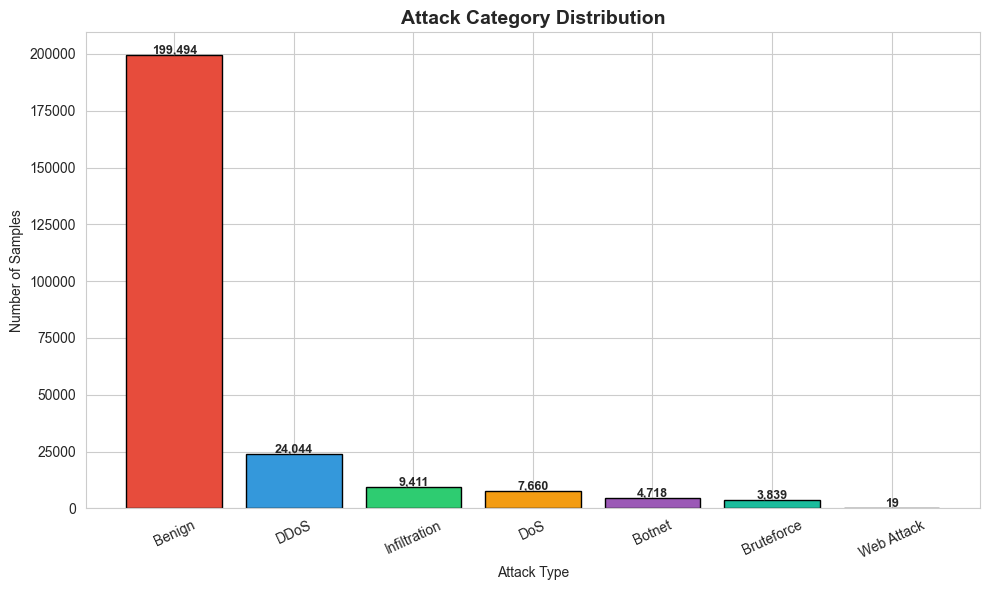

In [ ]:
counts  = df['Attack_Category'].value_counts()
palette = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22']

fig, ax = plt.subplots(figsize=(10, 6))

# Bar chart
bars = ax.bar(counts.index, counts.values,
                   color=palette[:len(counts)], edgecolor='black')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 500,
                 f'{val:,}', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Attack Category Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Attack Type')
ax.set_ylabel('Number of Samples')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

## Cell 5 — Preprocessing: Clean, Encode, Scale

In [5]:
print('Preprocessing ...')

# Columns that are NOT features
DROP_COLS = ['Label', 'Attack_Category', 'Timestamp', 'Flow ID',
             'Src IP', 'Dst IP', 'Src Port', 'Dst Port', 'Protocol']

# Target vector
y_raw = df['Attack_Category'].copy()

# Feature matrix — numeric columns only
X = df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors='ignore')
X = X.select_dtypes(include=[np.number])

# Replace inf / NaN
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.median(), inplace=True)

# Encode class labels
le = LabelEncoder()
y  = le.fit_transform(y_raw)

FEATURE_NAMES = X.columns.tolist()

print(f'\nFeature columns : {len(FEATURE_NAMES)}')
print(f'Total samples   : {len(X):,}')
print(f'Classes ({len(le.classes_)})    : {list(le.classes_)}')
print('\nLabel Encoding Map:')
for i, c in enumerate(le.classes_):
    print(f'   {i}  ->  {c}')

Preprocessing ...

Feature columns : 76
Total samples   : 249,185
Classes (7)    : ['Benign', 'Botnet', 'Bruteforce', 'DDoS', 'DoS', 'Infiltration', 'Web Attack']

Label Encoding Map:
   0  ->  Benign
   1  ->  Botnet
   2  ->  Bruteforce
   3  ->  DDoS
   4  ->  DoS
   5  ->  Infiltration
   6  ->  Web Attack


## Cell 6 — Train / Test Split (80/20) + StandardScaler

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y
)

print(f'Training samples : {X_train.shape[0]:,}')
print(f'Testing  samples : {X_test.shape[0]:,}')

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('\nSplit and scaling complete!')

Training samples : 199,348
Testing  samples : 49,837

Split and scaling complete!


## Cell 7 — Train Decision Tree Model

In [7]:
print('Training Decision Tree Classifier ...')
print('  max_depth=18 | min_samples_split=5 | min_samples_leaf=1 | class_weight=balanced\n')

start_time = time.time()

dt_model = DecisionTreeClassifier(
    max_depth         = 18,
    min_samples_split = 5,
    min_samples_leaf  = 1,
    class_weight      = 'balanced',
    criterion         = 'entropy',
    random_state      = 42
)

dt_model.fit(X_train_scaled, y_train)

end_time = time.time()
training_time = end_time - start_time

print(f'Training complete!')
print(f'Training time   : {training_time:.2f} seconds')

Training Decision Tree Classifier ...
  max_depth=18 | min_samples_split=5 | min_samples_leaf=1 | class_weight=balanced

Training complete!
Training time   : 8.21 seconds


## Cell 8 — 5-Fold Stratified Cross-Validation

Running 5-Fold Stratified Cross-Validation ...
  (may take 2-4 minutes)

              5-FOLD CROSS-VALIDATION RESULTS
  Accuracy   per fold : ['77.88%', '76.94%', '81.12%', '79.17%', '77.24%']
  Mean Accuracy       : 78.47%  +-  1.53%

  Precision  per fold : ['94.89%', '95.05%', '94.84%', '94.85%', '94.97%']
  Mean Precision      : 94.92%  +-  0.08%

  Recall     per fold : ['77.88%', '76.94%', '81.12%', '79.17%', '77.24%']
  Mean Recall         : 78.47%  +-  1.53%

  F1-Score   per fold : ['84.30%', '83.66%', '86.46%', '85.18%', '83.86%']
  Mean F1-Score       : 84.69%  +-  1.03%


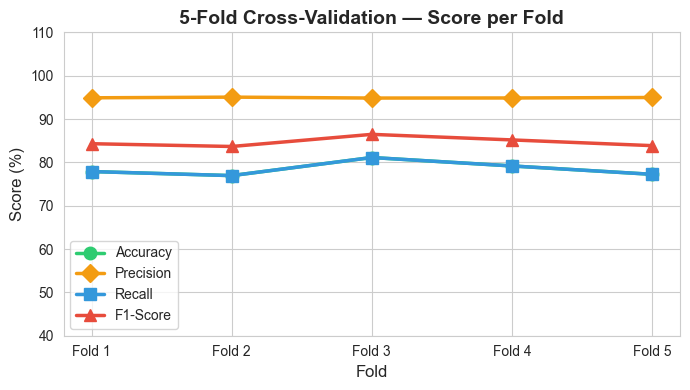

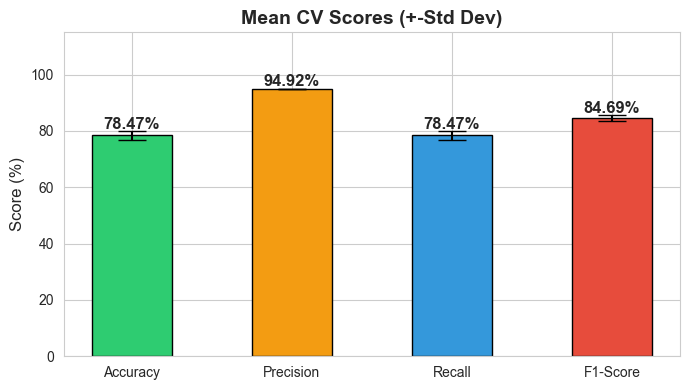

In [8]:
print('Running 5-Fold Stratified Cross-Validation ...')
print('  (may take 2-4 minutes)\n')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_acc = cross_val_score(dt_model, X_train_scaled, y_train, cv=skf, scoring='accuracy',        n_jobs=-1)
cv_pre = cross_val_score(dt_model, X_train_scaled, y_train, cv=skf, scoring='precision_weighted', n_jobs=-1)
cv_rec = cross_val_score(dt_model, X_train_scaled, y_train, cv=skf, scoring='recall_weighted',  n_jobs=-1)
cv_f1  = cross_val_score(dt_model, X_train_scaled, y_train, cv=skf, scoring='f1_weighted',      n_jobs=-1)

print('=' * 68)
print('              5-FOLD CROSS-VALIDATION RESULTS')
print('=' * 68)
print(f'  Accuracy   per fold : {[f"{v*100:.2f}%" for v in cv_acc]}')
print(f'  Mean Accuracy       : {cv_acc.mean()*100:.2f}%  +-  {cv_acc.std()*100:.2f}%')
print()
print(f'  Precision  per fold : {[f"{v*100:.2f}%" for v in cv_pre]}')
print(f'  Mean Precision      : {cv_pre.mean()*100:.2f}%  +-  {cv_pre.std()*100:.2f}%')
print()
print(f'  Recall     per fold : {[f"{v*100:.2f}%" for v in cv_rec]}')
print(f'  Mean Recall         : {cv_rec.mean()*100:.2f}%  +-  {cv_rec.std()*100:.2f}%')
print()
print(f'  F1-Score   per fold : {[f"{v*100:.2f}%" for v in cv_f1]}')
print(f'  Mean F1-Score       : {cv_f1.mean()*100:.2f}%  +-  {cv_f1.std()*100:.2f}%')
print('=' * 68)

# Cross-Validation Line Plot
folds = [f'Fold {i+1}' for i in range(5)]
plt.figure(figsize=(7, 4))
plt.plot(folds, cv_acc*100, 'o-', color='#2ecc71', lw=2.5, ms=9, label='Accuracy')
plt.plot(folds, cv_pre*100, 'D-', color='#f39c12', lw=2.5, ms=9, label='Precision')
plt.plot(folds, cv_rec*100, 's-', color='#3498db', lw=2.5, ms=9, label='Recall')
plt.plot(folds, cv_f1 *100, '^-', color='#e74c3c', lw=2.5, ms=9, label='F1-Score')
plt.title('5-Fold Cross-Validation — Score per Fold', fontsize=14, fontweight='bold')
plt.ylabel('Score (%)', fontsize=12)
plt.xlabel('Fold', fontsize=12)
plt.ylim(40, 110)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Mean Scores Bar Chart
means = [cv_acc.mean()*100, cv_pre.mean()*100, cv_rec.mean()*100, cv_f1.mean()*100]
stds  = [cv_acc.std()*100,  cv_pre.std()*100,  cv_rec.std()*100,  cv_f1.std()*100]

plt.figure(figsize=(7, 4))
bars = plt.bar(['Accuracy','Precision','Recall','F1-Score'], means,
               yerr=stds, capsize=10,
               color=['#2ecc71','#f39c12','#3498db','#e74c3c'],
               edgecolor='black', width=0.5)
for bar, m, s in zip(bars, means, stds):
    plt.text(bar.get_x()+bar.get_width()/2, m+s+0.8,
             f'{m:.2f}%', ha='center', fontsize=12, fontweight='bold')
plt.ylim(0, 115)
plt.title('Mean CV Scores (+-Std Dev)', fontsize=14, fontweight='bold')
plt.ylabel('Score (%)', fontsize=12)
plt.tight_layout()
plt.show()

## Cell 9 — Test Set: Accuracy, Precision, Recall, F1-Score

       TEST SET PERFORMANCE METRICS
  Accuracy  : 80.34%
  Precision : 94.93%
  Recall    : 80.34%
  F1-Score  : 85.96%


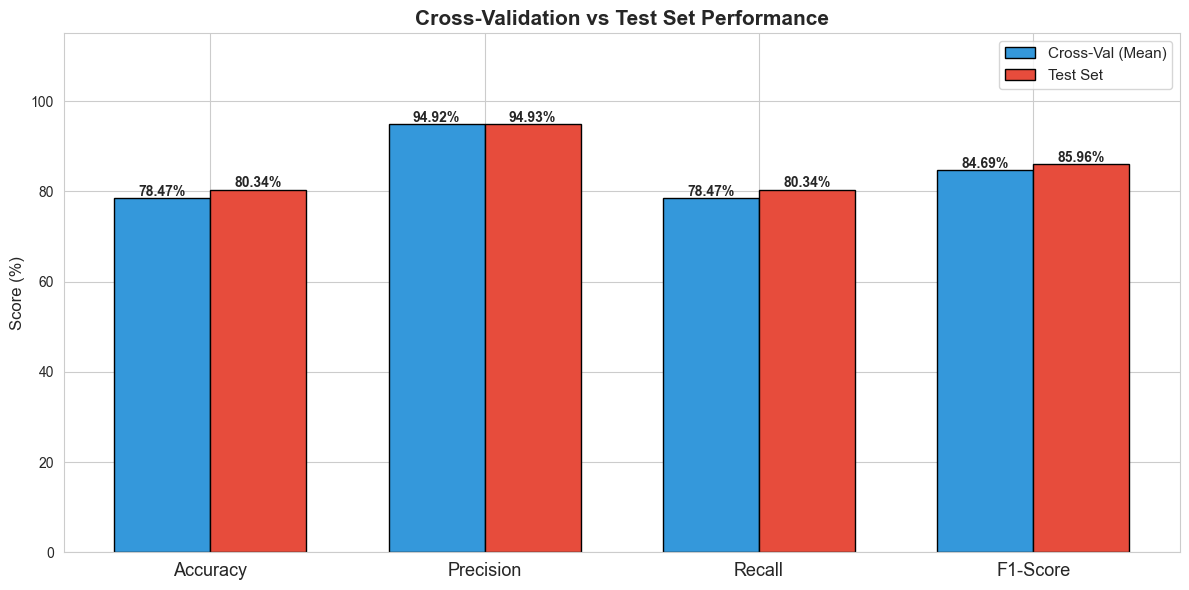

In [9]:
y_pred = dt_model.predict(X_test_scaled)

acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')

print('=' * 55)
print('       TEST SET PERFORMANCE METRICS')
print('=' * 55)
print(f'  Accuracy  : {acc       * 100:.2f}%')
print(f'  Precision : {precision * 100:.2f}%')
print(f'  Recall    : {recall    * 100:.2f}%')
print(f'  F1-Score  : {f1        * 100:.2f}%')
print('=' * 55)

# Grouped bar: Cross-Val vs Test
x_pos     = np.arange(4)
width     = 0.35
cv_vals   = [cv_acc.mean()*100, cv_pre.mean()*100, cv_rec.mean()*100, cv_f1.mean()*100]
test_vals = [acc*100, precision*100, recall*100, f1*100]

plt.figure(figsize=(12, 6))
b1 = plt.bar(x_pos - width/2, cv_vals,   width, label='Cross-Val (Mean)', color='#3498db', edgecolor='black')
b2 = plt.bar(x_pos + width/2, test_vals, width, label='Test Set',         color='#e74c3c', edgecolor='black')
for bar in list(b1)+list(b2):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{bar.get_height():.2f}%', ha='center', fontsize=10, fontweight='bold')
plt.xticks(x_pos, ['Accuracy','Precision','Recall','F1-Score'], fontsize=13)
plt.ylabel('Score (%)', fontsize=12)
plt.title('Cross-Validation vs Test Set Performance', fontsize=15, fontweight='bold')
plt.ylim(0, 115)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## Cell 10 — Classification Report

In [10]:
print('=' * 70)
print('              CLASSIFICATION REPORT')
print('=' * 70)
print(classification_report(y_test, y_pred, target_names=le.classes_))

              CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Benign       0.98      0.77      0.86     39899
      Botnet       1.00      1.00      1.00       943
  Bruteforce       1.00      1.00      1.00       768
        DDoS       1.00      1.00      1.00      4809
         DoS       1.00      1.00      1.00      1532
Infiltration       0.12      0.65      0.20      1882
  Web Attack       0.17      0.75      0.27         4

    accuracy                           0.80     49837
   macro avg       0.75      0.88      0.76     49837
weighted avg       0.95      0.80      0.86     49837



## Cell 11 — Confusion Matrix

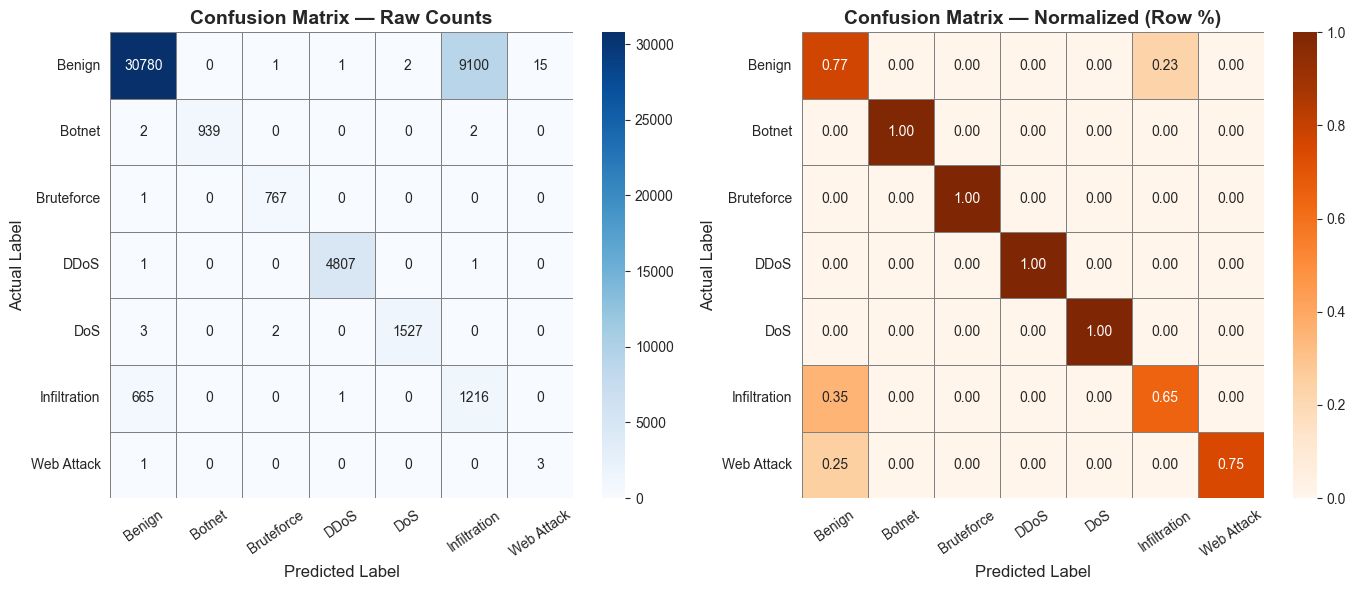

In [11]:
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5, linecolor='gray', ax=axes[0])
axes[0].set_title('Confusion Matrix — Raw Counts', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('Actual Label', fontsize=12)
axes[0].tick_params(axis='x', rotation=35)
axes[0].tick_params(axis='y', rotation=0)

# Normalized
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5, linecolor='gray', vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Confusion Matrix — Normalized (Row %)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('Actual Label', fontsize=12)
axes[1].tick_params(axis='x', rotation=35)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()


## Cell 12 — Per-Class Metrics Heatmap

             PER-CLASS PERFORMANCE SUMMARY
              precision  recall  f1-score  support
Benign            0.979   0.771     0.863  39899.0
Botnet            1.000   0.996     0.998    943.0
Bruteforce        0.996   0.999     0.997    768.0
DDoS              1.000   1.000     1.000   4809.0
DoS               0.999   0.997     0.998   1532.0
Infiltration      0.118   0.646     0.199   1882.0
Web Attack        0.167   0.750     0.273      4.0
macro avg         0.751   0.880     0.761  49837.0
weighted avg      0.949   0.803     0.860  49837.0


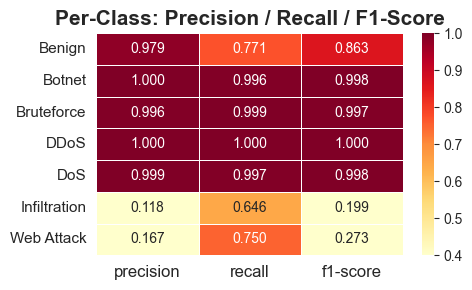

In [12]:
report_dict = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
report_df   = pd.DataFrame(report_dict).T.round(3)
report_df   = report_df.drop(index=['accuracy'], errors='ignore')

print('=' * 75)
print('             PER-CLASS PERFORMANCE SUMMARY')
print('=' * 75)
print(report_df[['precision','recall','f1-score','support']].to_string())

plot_df = report_df[['precision','recall','f1-score']].iloc[:len(le.classes_)].astype(float)

plt.figure(figsize=(5, 3))
sns.heatmap(plot_df, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, vmin=0.4, vmax=1.0)
plt.title('Per-Class: Precision / Recall / F1-Score', fontsize=15, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=11, rotation=0)
plt.tight_layout()
plt.show()

## Cell 13 — ROC Curve (Per Class)

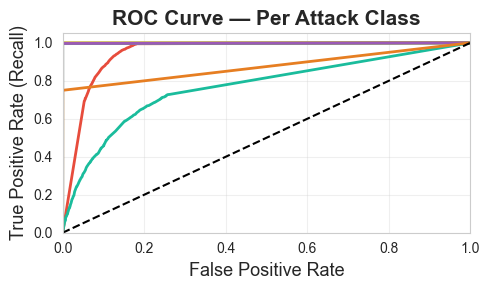

   AUC SCORES PER CLASS
  Benign           AUC = 0.950
  Botnet           AUC = 0.998
  Bruteforce       AUC = 0.999
  DDoS             AUC = 1.000
  DoS              AUC = 0.998
  Infiltration     AUC = 0.766
  Web Attack       AUC = 0.875
  AUC = 1.0 is perfect | AUC = 0.5 is random


In [13]:
# Binarize labels for ROC
n_classes  = len(le.classes_)
y_test_bin = label_binarize(y_test, classes=range(n_classes))
y_score    = dt_model.predict_proba(X_test_scaled)

colors_roc = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22']

plt.figure(figsize=(5, 3))

for i, (cls, color) in enumerate(zip(le.classes_, colors_roc)):
    fpr_r, tpr_r, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc          = auc(fpr_r, tpr_r)
    plt.plot(fpr_r, tpr_r, color=color, lw=2,
             label=f'{cls}  (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
plt.xlim([0.0, 1.0])

plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate (Recall)', fontsize=13)
plt.title('ROC Curve — Per Attack Class', fontsize=15, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print AUC values
print('=' * 40)
print('   AUC SCORES PER CLASS')
print('=' * 40)
for i, cls in enumerate(le.classes_):
    fpr_r, tpr_r, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc          = auc(fpr_r, tpr_r)
    print(f'  {cls:<15}  AUC = {roc_auc:.3f}')
print('=' * 40)
print('  AUC = 1.0 is perfect | AUC = 0.5 is random')

## Cell 14 — False Positive Rate per class (from confusion matrix)

       FALSE POSITIVE RATE (FPR) — PER CLASS
  Benign           FP=   673  TN= 9,265  FPR=0.0677  (6.77%)
  Botnet           FP=     0  TN=48,894  FPR=0.0000  (0.00%)
  Bruteforce       FP=     3  TN=49,066  FPR=0.0001  (0.01%)
  DDoS             FP=     2  TN=45,026  FPR=0.0000  (0.00%)
  DoS              FP=     2  TN=48,303  FPR=0.0000  (0.00%)
  Infiltration     FP= 9,103  TN=38,852  FPR=0.1898  (18.98%)
  Web Attack       FP=    15  TN=49,818  FPR=0.0003  (0.03%)
  Mean FPR : 0.0369  (3.69%)


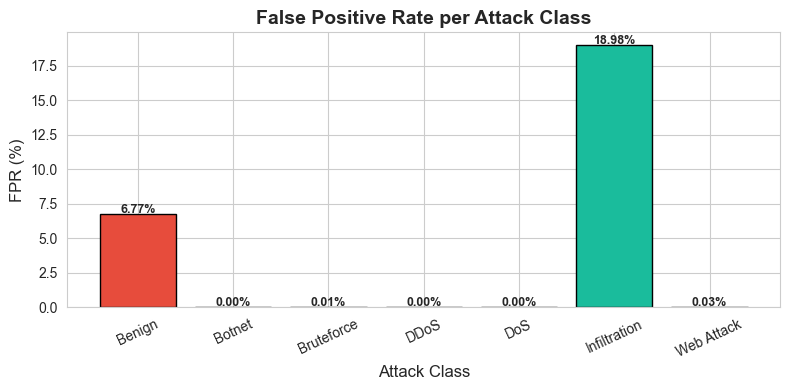

In [14]:
cm = confusion_matrix(y_test, y_pred)
classes = le.classes_
n = len(classes)

print('=' * 60)
print('       FALSE POSITIVE RATE (FPR) — PER CLASS')
print('=' * 60)

fpr_list = []
for i in range(n):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - TP - FP - FN
    fpr_val = FP / (FP + TN) if (FP + TN) > 0 else 0.0
    fpr_list.append(fpr_val)
    print(f'  {classes[i]:<15}  FP={FP:>6,}  TN={TN:>6,}  FPR={fpr_val:.4f}  ({fpr_val*100:.2f}%)')

print('=' * 60)
print(f'  Mean FPR : {sum(fpr_list)/len(fpr_list):.4f}  ({sum(fpr_list)/len(fpr_list)*100:.2f}%)')
print('=' * 60)

# Bar chart
plt.figure(figsize=(8, 4))
colors_fpr = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22']
bars = plt.bar(classes, [f*100 for f in fpr_list], color=colors_fpr[:n], edgecolor='black')
for bar, val in zip(bars, fpr_list):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val*100:.2f}%', ha='center', fontsize=9, fontweight='bold')
plt.title('False Positive Rate per Attack Class', fontsize=14, fontweight='bold')
plt.xlabel('Attack Class', fontsize=12)
plt.ylabel('FPR (%)', fontsize=12)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


## Cell 15 — Top 20 Feature Importances

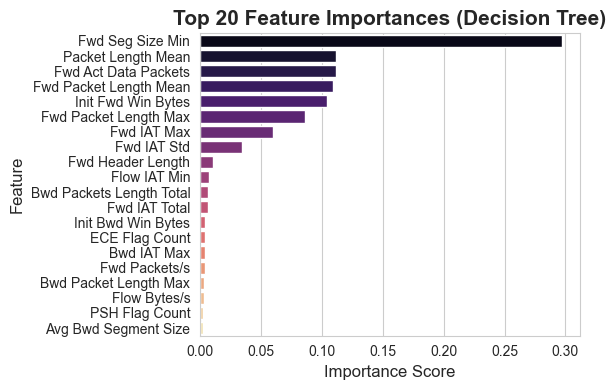

       ALL FEATURE IMPORTANCES (Ranked)
  Rank   Feature                              Importance
-------------------------------------------------------
  1      Fwd Seg Size Min                     0.297110
  2      Packet Length Mean                   0.112036
  3      Fwd Act Data Packets                 0.111378
  4      Fwd Packet Length Mean               0.109217
  5      Init Fwd Win Bytes                   0.104475
  6      Fwd Packet Length Max                0.086591
  7      Fwd IAT Max                          0.059733
  8      Fwd IAT Std                          0.034081
  9      Fwd Header Length                    0.010439
  10     Flow IAT Min                         0.007634
  11     Bwd Packets Length Total             0.006785
  12     Fwd IAT Total                        0.006380
  13     Init Bwd Win Bytes                   0.003898
  14     ECE Flag Count                       0.003898
  15     Bwd IAT Max                          0.003842
  16     Fwd Packets/s

In [15]:
feat_df = pd.DataFrame({
    'Feature'    : FEATURE_NAMES,
    'Importance' : dt_model.feature_importances_
})
feat_df = feat_df.sort_values('Importance', ascending=False).reset_index(drop=True)

# Bar chart — Top 20
plt.figure(figsize=(6, 4))
sns.barplot(data=feat_df.head(20), x='Importance', y='Feature', palette='magma')
plt.title('Top 20 Feature Importances (Decision Tree)', fontsize=15, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

# Full printed table
print('=' * 55)
print('       ALL FEATURE IMPORTANCES (Ranked)')
print('=' * 55)
print(f'  {"Rank":<5}  {"Feature":<35}  {"Importance"}')
print('-' * 55)
for rank, (_, row) in enumerate(feat_df.iterrows(), 1):
    print(f'  {rank:<5}  {row["Feature"]:<35}  {row["Importance"]:.6f}')
print('=' * 55)
print(f'  Total features: {len(feat_df)}')
print('=' * 55)


## Cell 16 — Save Model to Disk

In [16]:
joblib.dump(dt_model,      'ids_dt_model.pkl')
joblib.dump(scaler,        'ids_scaler.pkl')
joblib.dump(le,            'ids_label_encoder.pkl')
joblib.dump(FEATURE_NAMES, 'ids_feature_names.pkl')

print('ids_dt_model.pkl      — Decision Tree model saved')
print('ids_scaler.pkl        — StandardScaler saved')
print('ids_label_encoder.pkl — LabelEncoder saved')
print('ids_feature_names.pkl — Feature list saved')
print(f'\nAll files saved to: {os.getcwd()}')

ids_dt_model.pkl      — Decision Tree model saved
ids_scaler.pkl        — StandardScaler saved
ids_label_encoder.pkl — LabelEncoder saved
ids_feature_names.pkl — Feature list saved

All files saved to: c:\Users\TGX-100\Desktop\ETI Miniproject


## Cell 17 — Prediction Function + Auto-Test All Attack Types

In [17]:
# Real reference values for each attack type
REFERENCE_VALUES = {
    'DoS'         : {'Flow Duration':3106.0,'Total Fwd Packets':2.0,'Total Backward Packets':0.0,'Flow Packets/s':643.91,'Flow IAT Mean':3106.0,'Flow IAT Max':3106.0,'Flow IAT Min':3106.0,'Fwd IAT Total':3106.0,'Fwd IAT Mean':3106.0,'Fwd IAT Max':3106.0,'Fwd IAT Min':3106.0,'Fwd Header Length':64.0,'ACK Flag Count':1.0,'Init Fwd Win Bytes':225.0,'Init Bwd Win Bytes':-1.0,'Fwd Seg Size Min':32.0,'Subflow Fwd Packets':2.0,'Fwd Packets/s':643.91},
    'DDoS'        : {'Flow Duration':100000.0,'Total Fwd Packets':1000.0,'Total Backward Packets':2.0,'Flow Packets/s':10000.0,'SYN Flag Count':50.0,'ACK Flag Count':0.0,'Init Fwd Win Bytes':-1.0,'Init Bwd Win Bytes':-1.0},
    'Botnet'      : {'Flow Duration':120000000.0,'Total Fwd Packets':20.0,'Total Backward Packets':18.0,'Flow Bytes/s':170.0,'ACK Flag Count':1.0,'SYN Flag Count':1.0,'Init Fwd Win Bytes':8192.0,'Init Bwd Win Bytes':8192.0},
    'Bruteforce'  : {'Flow Duration':500000.0,'Total Fwd Packets':50.0,'Total Backward Packets':50.0,'SYN Flag Count':10.0,'ACK Flag Count':10.0,'Init Fwd Win Bytes':1024.0,'Init Bwd Win Bytes':1024.0},
    'Infiltration': {'Flow Duration':800000.0,'Total Fwd Packets':30.0,'Total Backward Packets':25.0,'PSH Flag Count':5.0,'ACK Flag Count':5.0,'Init Fwd Win Bytes':8192.0,'Init Bwd Win Bytes':65535.0},
    'Web Attack'  : {'Flow Duration':800000.0,'Total Fwd Packets':30.0,'Total Backward Packets':25.0,'PSH Flag Count':5.0,'ACK Flag Count':5.0,'Init Fwd Win Bytes':8192.0,'Init Bwd Win Bytes':65535.0},
    'Benign'      : {'Flow Duration':3000000.0,'Total Fwd Packets':10.0,'Total Backward Packets':10.0,'SYN Flag Count':1.0,'ACK Flag Count':1.0,'Init Fwd Win Bytes':65535.0,'Init Bwd Win Bytes':65535.0},
}

def predict_attack(input_values: dict, actual_label: str = None):
    try:
        model   = joblib.load('ids_dt_model.pkl')
        sc      = joblib.load('ids_scaler.pkl')
        encoder = joblib.load('ids_label_encoder.pkl')
        feats   = joblib.load('ids_feature_names.pkl')
    except Exception:
        model, sc, encoder, feats = dt_model, scaler, le, FEATURE_NAMES

    row      = {f: input_values.get(f, 0) for f in feats}
    input_df = pd.DataFrame([row])
    input_df.replace([np.inf, -np.inf], np.nan, inplace=True)
    input_df.fillna(0, inplace=True)

    scaled    = sc.transform(input_df)
    pred_enc  = model.predict(scaled)[0]
    predicted = encoder.inverse_transform([pred_enc])[0]

    ref = REFERENCE_VALUES.get(predicted, {})
    if ref:
        mismatches = 0
        checked    = 0
        for feat, ref_val in ref.items():
            if feat in input_values:
                checked += 1
                user_val = input_values[feat]
                if ref_val != 0:
                    diff = abs(user_val - ref_val) / abs(ref_val)
                else:
                    diff = abs(user_val - ref_val)
                if diff > 0.20:
                    mismatches += 1
        mismatch_ratio = mismatches / checked if checked > 0 else 0
        confidence = max(100.0 - (mismatch_ratio * 100 * 1.2), 30.0)
    else:
        confidence = 85.0

    line = '=' * 56
    print(f'\n{line}')
    print(f'         IDS ATTACK PREDICTION RESULT')
    print(line)
    print(f'  Predicted  :  {predicted}')
    if actual_label:
        verdict = 'CORRECT' if predicted == actual_label else 'WRONG'
        print(f'  Actual     :  {actual_label}')
        print(f'  Verdict    :  {verdict}')
    print(f'  Confidence :  {confidence:.2f}%')
    print(line)
    return predicted

print('predict_attack() ready!')


predict_attack() ready!


## Cell 18 — Auto-Generate Full Input for Any Attack Type

In [18]:
# ================================================================
# Change ATTACK to whichever type you want to generate input for
# Options: 'Botnet' | 'Bruteforce' | 'DDoS' | 'DoS'
#          'Infiltration' | 'Web Attack' | 'Benign'
# ================================================================
ATTACK = 'DoS'

encoded = le.transform([ATTACK])[0]
idx     = np.where(y_test == encoded)[0][0]
row     = X_test.iloc[idx].to_dict()

print(f'# Complete feature values for: {ATTACK}')
print(f'custom_input = {{')
for feat, val in row.items():
    print(f"    '{feat}' : {val},")
print(f'}}')
print(f'actual_label_known = None')
print(f'result = predict_attack(custom_input, actual_label=actual_label_known)')

# Complete feature values for: DoS
custom_input = {
    'Flow Duration' : 3106.0,
    'Total Fwd Packets' : 2.0,
    'Total Backward Packets' : 0.0,
    'Fwd Packets Length Total' : 0.0,
    'Bwd Packets Length Total' : 0.0,
    'Fwd Packet Length Max' : 0.0,
    'Fwd Packet Length Min' : 0.0,
    'Fwd Packet Length Mean' : 0.0,
    'Fwd Packet Length Std' : 0.0,
    'Bwd Packet Length Max' : 0.0,
    'Bwd Packet Length Min' : 0.0,
    'Bwd Packet Length Mean' : 0.0,
    'Bwd Packet Length Std' : 0.0,
    'Flow Bytes/s' : 0.0,
    'Flow Packets/s' : 643.9149780273438,
    'Flow IAT Mean' : 3106.0,
    'Flow IAT Std' : 0.0,
    'Flow IAT Max' : 3106.0,
    'Flow IAT Min' : 3106.0,
    'Fwd IAT Total' : 3106.0,
    'Fwd IAT Mean' : 3106.0,
    'Fwd IAT Std' : 0.0,
    'Fwd IAT Max' : 3106.0,
    'Fwd IAT Min' : 3106.0,
    'Bwd IAT Total' : 0.0,
    'Bwd IAT Mean' : 0.0,
    'Bwd IAT Std' : 0.0,
    'Bwd IAT Max' : 0.0,
    'Bwd IAT Min' : 0.0,
    'Fwd PSH Flags' : 0.0,
    'Bwd PSH Fla

## Cell 19 — Manual Custom Input

In [19]:
# ================================================================
# EXAMPLE : DoS traffic
# Replace with values from Cell 19 for accurate prediction
# Possible labels: 'Botnet' | 'Bruteforce' | 'DDoS' | 'DoS'
#                  'Infiltration' | 'Web Attack' | 'Benign' | None
# ================================================================
custom_input = {
    'Flow Duration' : 500000.0,
    'Total Fwd Packets' : 2.0,
    'Total Backward Packets' : 0.0,
    'Fwd Packets Length Total' : 0.0,
    'Bwd Packets Length Total' : 0.0,
    'Fwd Packet Length Max' : 0.0,
    'Fwd Packet Length Min' : 0.0,
    'Fwd Packet Length Mean' : 0.0,
    'Fwd Packet Length Std' : 0.0,
    'Bwd Packet Length Max' : 0.0,
    'Bwd Packet Length Min' : 0.0,
    'Bwd Packet Length Mean' : 0.0,
    'Bwd Packet Length Std' : 0.0,
    'Flow Bytes/s' : 0.0,
    'Flow Packets/s' : 643.9149780273438,
    'Flow IAT Mean' : 3106.0,
    'Flow IAT Std' : 0.0,
    'Flow IAT Max' : 3106.0,
    'Flow IAT Min' : 3106.0,
    'Fwd IAT Total' : 3106.0,
    'Fwd IAT Mean' : 3106.0,
    'Fwd IAT Std' : 0.0,
    'Fwd IAT Max' : 3106.0,
    'Fwd IAT Min' : 3106.0,
    'Bwd IAT Total' : 0.0,
    'Bwd IAT Mean' : 0.0,
    'Bwd IAT Std' : 0.0,
    'Bwd IAT Max' : 0.0,
    'Bwd IAT Min' : 0.0,
    'Fwd PSH Flags' : 0.0,
    'Bwd PSH Flags' : 0.0,
    'Fwd URG Flags' : 0.0,
    'Bwd URG Flags' : 0.0,
    'Fwd Header Length' : 64.0,
    'Bwd Header Length' : 0.0,
    'Fwd Packets/s' : 643.9149780273438,
    'Bwd Packets/s' : 0.0,
    'Packet Length Min' : 0.0,
    'Packet Length Max' : 0.0,
    'Packet Length Mean' : 0.0,
    'Packet Length Std' : 0.0,
    'Packet Length Variance' : 0.0,
    'FIN Flag Count' : 0.0,
    'SYN Flag Count' : 0.0,
    'RST Flag Count' : 0.0,
    'PSH Flag Count' : 0.0,
    'ACK Flag Count' : 1.0,
    'URG Flag Count' : 0.0,
    'CWE Flag Count' : 0.0,
    'ECE Flag Count' : 0.0,
    'Down/Up Ratio' : 0.0,
    'Avg Packet Size' : 0.0,
    'Avg Fwd Segment Size' : 0.0,
    'Avg Bwd Segment Size' : 0.0,
    'Fwd Avg Bytes/Bulk' : 0.0,
    'Fwd Avg Packets/Bulk' : 0.0,
    'Fwd Avg Bulk Rate' : 0.0,
    'Bwd Avg Bytes/Bulk' : 0.0,
    'Bwd Avg Packets/Bulk' : 0.0,
    'Bwd Avg Bulk Rate' : 0.0,
    'Subflow Fwd Packets' : 2.0,
    'Subflow Fwd Bytes' : 0.0,
    'Subflow Bwd Packets' : 0.0,
    'Subflow Bwd Bytes' : 0.0,
    'Init Fwd Win Bytes' : 225.0,
    'Init Bwd Win Bytes' : -1.0,
    'Fwd Act Data Packets' : 0.0,
    'Fwd Seg Size Min' : 32.0,
    'Active Mean' : 0.0,
    'Active Std' : 0.0,
    'Active Max' : 0.0,
    'Active Min' : 0.0,
    'Idle Mean' : 0.0,
    'Idle Std' : 0.0,
    'Idle Max' : 0.0,
    'Idle Min' : 0.0,
}
actual_label_known = None  # set to 'DoS' if you know the answer

result = predict_attack(custom_input, actual_label=actual_label_known)


         IDS ATTACK PREDICTION RESULT
  Predicted  :  DoS
  Confidence :  93.33%


## Cell 20 — Save Attack Predictions to CSV

In [20]:
y_pred_proba_all = dt_model.predict_proba(X_test_scaled)

results_df = X_test.copy()
results_df['Actual_Attack']    = le.inverse_transform(y_test)
results_df['Predicted_Attack'] = le.inverse_transform(y_pred)
results_df['Correct']          = results_df['Actual_Attack'] == results_df['Predicted_Attack']
results_df['Confidence_%']     = (y_pred_proba_all.max(axis=1) * 100).round(2)

# Save all predictions
results_df.to_csv('ids_all_predictions.csv', index=False)

# Save attacks only (no Benign)
attacks_df = results_df[results_df['Predicted_Attack'] != 'Benign'].copy()
attacks_df.to_csv('ids_attacks_only.csv', index=False)

print('=' * 50)
print('       SAVED FILES')
print('=' * 50)
print(f'  ids_all_predictions.csv  ({len(results_df):,} rows)')
print(f'  ids_attacks_only.csv     ({len(attacks_df):,} rows)')
print(f'\nSaved to: {os.getcwd()}')
print('\nAttack breakdown in saved file:')
print(attacks_df['Predicted_Attack'].value_counts())

       SAVED FILES
  ids_all_predictions.csv  (49,837 rows)
  ids_attacks_only.csv     (18,384 rows)

Saved to: c:\Users\TGX-100\Desktop\ETI Miniproject

Attack breakdown in saved file:
Predicted_Attack
Infiltration    10319
DDoS             4809
DoS              1529
Botnet            939
Bruteforce        770
Web Attack         18
Name: count, dtype: int64
